# Step 5 - WEAT and Monotonicity Testing

                This notebook runs the primary WEAT specification across the four seniority embeddings,
                reports effect sizes and p-values, and evaluates whether the ordering is monotonic.


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

SRC_PATH = os.path.abspath("../src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from linkedin_experiment.weat import run_weat_suite

seed_results, summary, monotonicity = run_weat_suite(seeds=[7, 17, 29], permutations=1000)
summary, monotonicity


(              test_name       group  effect_size_mean  effect_size_std  \
 0  gender_career_family       entry          0.537567         0.149802   
 1  gender_career_family  leadership          0.011949         0.111518   
 2  gender_career_family         mid          1.091682         0.032493   
 3  gender_career_family      senior          0.870784         0.077595   
 
    p_value_mean  coverage_targets_a  coverage_targets_b  coverage_attrs_a  \
 0      0.238845                 4.0                 5.0              10.0   
 1      0.493880                 5.0                 6.0              10.0   
 2      0.103286                 4.0                 4.0              10.0   
 3      0.107612                 4.0                 5.0              10.0   
 
    coverage_attrs_b  
 0               8.0  
 1               8.0  
 2               7.0  
 3              10.0  ,
               test_name  seed_runs  entry_mean  mid_mean  senior_mean  \
 0  gender_career_family          3    0.

In [2]:
seed_results = pd.read_csv("../results/weat/weat_seed_results.csv")
summary = pd.read_csv("../results/weat/weat_summary.csv")
monotonicity = pd.read_csv("../results/weat/monotonicity_summary.csv")
seed_results.head(), summary, monotonicity


(              test_name  coverage_targets_a  coverage_targets_b  \
 0  gender_career_family                   4                   5   
 1  gender_career_family                   4                   5   
 2  gender_career_family                   4                   5   
 3  gender_career_family                   4                   4   
 4  gender_career_family                   4                   4   
 
    coverage_attrs_a  coverage_attrs_b  effect_size   p_value  group  seed  \
 0                10                 8     0.567635  0.212598  entry     7   
 1                10                 8     0.375011  0.322835  entry    17   
 2                10                 8     0.670054  0.181102  entry    29   
 3                10                 7     1.103397  0.126761    mid     7   
 4                10                 7     1.116692  0.098592    mid    17   
 
                                           model_path  
 0  D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...  
 1  D:/F

## Report Visual Aids

These plots read the saved WEAT outputs only, so you can refresh the report visuals without rerunning permutations.


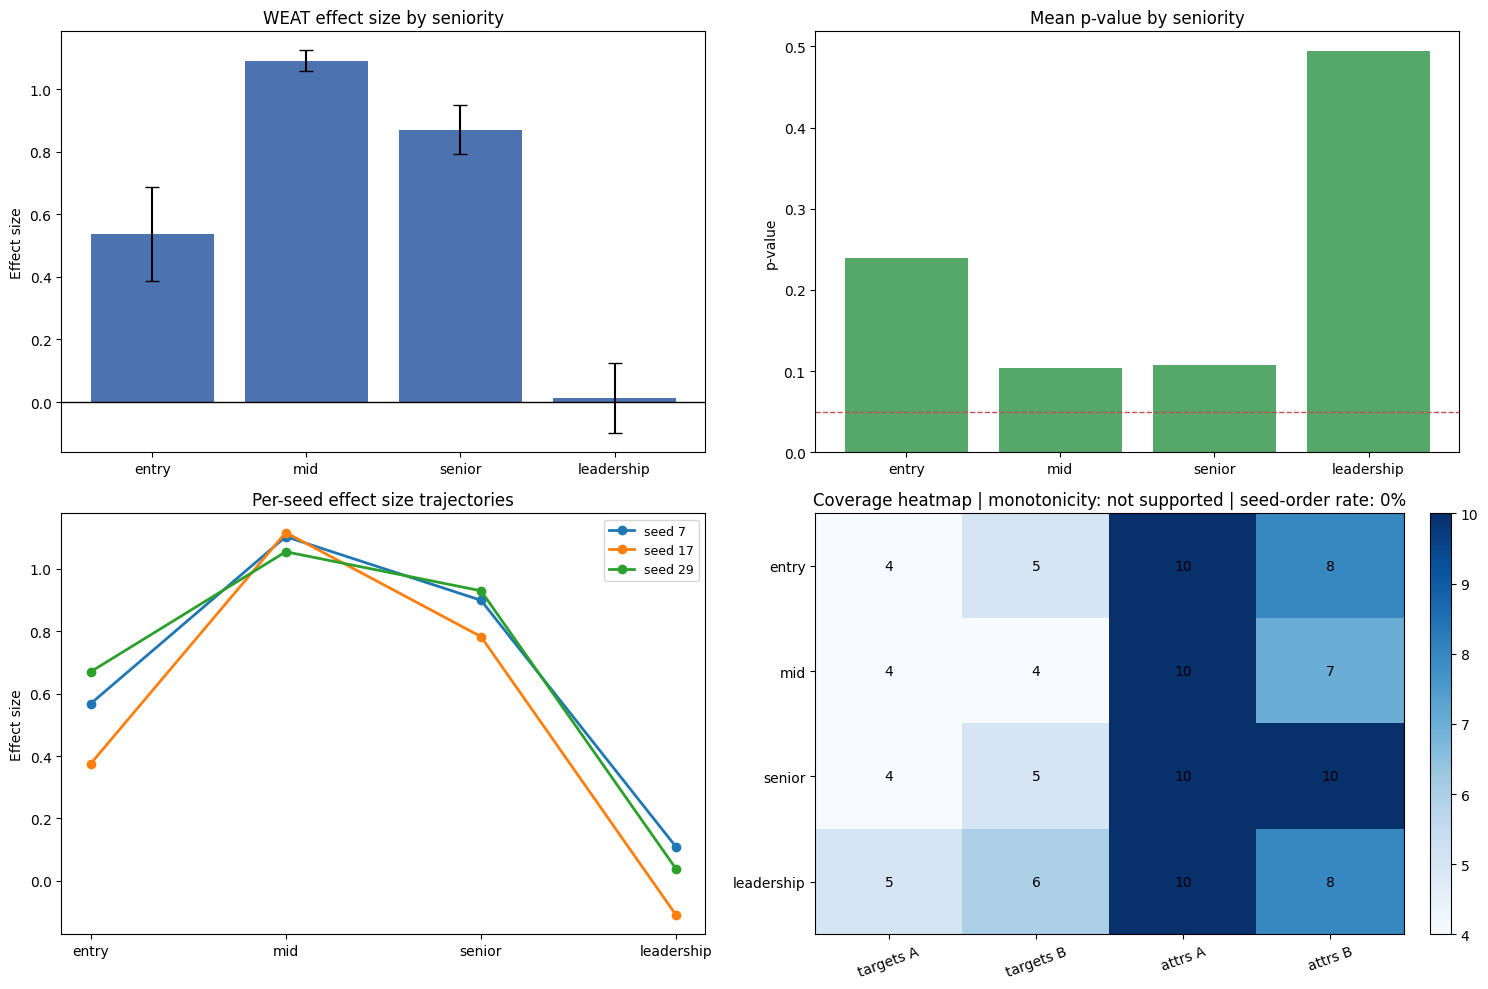

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

group_order = ["entry", "mid", "senior", "leadership"]
weat_dir = Path("../results/weat")

seed_results = pd.read_csv(weat_dir / "weat_seed_results.csv")
summary = pd.read_csv(weat_dir / "weat_summary.csv").set_index("group").reindex(group_order).reset_index()
monotonicity = pd.read_csv(weat_dir / "monotonicity_summary.csv")
mono = monotonicity.iloc[0]
seed_order_rate = mono["seed_order_rate"]
seed_order_label = "n/a" if pd.isna(seed_order_rate) else f"{seed_order_rate:.0%}"

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(summary["group"], summary["effect_size_mean"], yerr=summary["effect_size_std"], capsize=5, color="#4c72b0")
axes[0, 0].set_title("WEAT effect size by seniority")
axes[0, 0].set_ylabel("Effect size")
axes[0, 0].axhline(0, color="black", linewidth=1)

axes[0, 1].bar(summary["group"], summary["p_value_mean"], color="#55a868")
axes[0, 1].axhline(0.05, color="#c44e52", linestyle="--", linewidth=1)
axes[0, 1].set_title("Mean p-value by seniority")
axes[0, 1].set_ylabel("p-value")

for seed, seed_df in seed_results.groupby("seed"):
    ordered = seed_df.set_index("group").reindex(group_order)
    axes[1, 0].plot(group_order, ordered["effect_size"], marker="o", linewidth=2, label=f"seed {seed}")
axes[1, 0].set_title("Per-seed effect size trajectories")
axes[1, 0].set_ylabel("Effect size")
axes[1, 0].legend(title="", fontsize=9)

coverage_cols = ["coverage_targets_a", "coverage_targets_b", "coverage_attrs_a", "coverage_attrs_b"]
coverage = summary.set_index("group").reindex(group_order)[coverage_cols]
image = axes[1, 1].imshow(coverage.fillna(0), cmap="Blues", aspect="auto")
axes[1, 1].set_title(
    f"Coverage heatmap | monotonicity: {mono['interpretation'].replace('_', ' ')} | seed-order rate: {seed_order_label}"
)
axes[1, 1].set_xticks(range(len(coverage_cols)))
axes[1, 1].set_xticklabels(["targets A", "targets B", "attrs A", "attrs B"], rotation=20)
axes[1, 1].set_yticks(range(len(group_order)))
axes[1, 1].set_yticklabels(group_order)
for row_idx in range(len(group_order)):
    for col_idx in range(len(coverage_cols)):
        value = coverage.iloc[row_idx, col_idx]
        label = "NA" if pd.isna(value) else int(value)
        axes[1, 1].text(col_idx, row_idx, label, ha="center", va="center", color="black")
fig.colorbar(image, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plot_name = "Step 5 - Report Visual Aids"
plt.savefig(f"{plot_name}.png", dpi=300, bbox_inches="tight")
plt.show()
